## **Proyecto 5: Touch**

Ya no solo mostramos información: el ESP32 va a recibir acciones tuyas desde la pantalla.

Perfecto. Este ejemplo usa el controlador táctil FT6336U por I²C. Los pines del ejemplo oficial son:

- SDA → GPIO 2
- SCL → GPIO 1
- RST → no usado
- INT → no usado

```bash
#include "FT6336U.h"

#define I2C_SDA 2
#define I2C_SCL 1
#define RST_N_PIN -1
#define INT_N_PIN -1

FT6336U ft6336u(I2C_SDA, I2C_SCL, RST_N_PIN, INT_N_PIN); 
FT6336U_TouchPointType tp; 
int state = 0;

void setup() {
    Serial.begin(115200); 
    ft6336u.begin(); 
    Serial.print("FT6336U Firmware Version: "); 
    Serial.println(ft6336u.read_firmware_id());  
    Serial.print("FT6336U Device Mode: "); 
    Serial.println(ft6336u.read_device_mode());  
}

void loop() {
    tp = ft6336u.scan(); 
    char tempString[128]; 
    sprintf(tempString, "FT6336U TD Count %d / TD1 (%d, %4d, %4d) / TD2 (%d, %4d, %4d)\r\n", tp.touch_count, tp.tp[0].status, tp.tp[0].x, tp.tp[0].y, tp.tp[1].status, tp.tp[1].x, tp.tp[1].y); 
    Serial.print(tempString); 
    delay(100);
}

```

El código simplemente escanea la pantalla cada 100 ms y manda por el Monitor Serie cuántos dedos detecta y las coordenadas X/Y de hasta dos puntos táctiles.

Antes de compilar, necesitamos instalar la librería correspondiente que viene en el paquete oficial de Freenove

FT6336U.zip

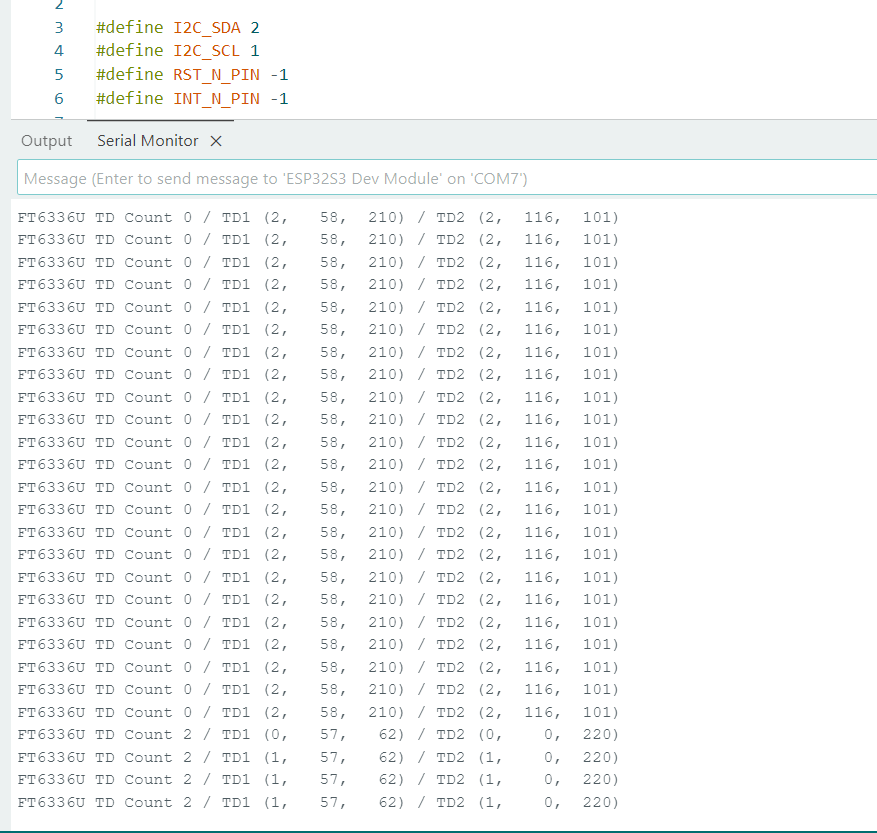

Perfecto: el controlador táctil FT6336U está funcionando y el ESP32 está recibiendo las coordenadas correctamente

Quedó validado el touch multitáctil de 2 puntos. ✅

**Eso nos deja con una base muy buena:**

- TFT funcionando
- Touch funcionando
- Lectura de 0, 1 y 2 dedos correcta
- Coordenadas X/Y respondiendo bien

El siguiente proyecto que conviene hacer es Sketch_09_LVGL, porque ahí empezamos a crear una interfaz gráfica real: botones, etiquetas, controles, etc.

Ese proyecto ya combina lo que aprendimos en los dos anteriores:

- la pantalla muestra elementos gráficos;
- el touch permite interactuar con ellos.